# Hand Gesture Recognition using Convolutional Neural Network (CNN)

## 1. Project Title and Objective
**Project Title:** Hand Gesture Recognition using Convolutional Neural Network (CNN)
**Objective:** Develop a hand gesture recognition model that can accurately identify and classify different hand gestures from image data, enabling intuitive human-computer interaction and gesture-based control systems. This is Task 04 of the SkillCraft Technology Machine Learning Internship.

## 2. Import Required Libraries

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

## 3. Load Dataset
Provide the path to your dataset below. The dataset should ideally have subfolders for each gesture class.

In [2]:
DATASET_PATH = "D:\leapGestRecog"

print(f"Dataset path set to: {DATASET_PATH}")

Dataset path set to: D:\leapGestRecog


## 4. Explore the Dataset
Let's see how many classes (gestures) we have and count the images in each class.

In [3]:
if os.path.exists(DATASET_PATH):
    # Count total images per gesture across all subjects
    gesture_counts = {}
    for subject_folder in os.listdir(DATASET_PATH):
        subject_path = os.path.join(DATASET_PATH, subject_folder)
        if not os.path.isdir(subject_path): continue
        for gesture_folder in os.listdir(subject_path):
            gesture_path = os.path.join(subject_path, gesture_folder)
            if not os.path.isdir(gesture_path): continue
            gesture_counts[gesture_folder] = gesture_counts.get(gesture_folder, 0) + len(os.listdir(gesture_path))
            
    print(f"Total unique gestures found: {len(gesture_counts)}")
    for gesture, count in gesture_counts.items():
        print(f" - {gesture}: {count} images total")
else:
    print("Dataset path not found. Please update DATASET_PATH.")


Total unique gestures found: 10
 - 01_palm: 1600 images total
 - 02_l: 1600 images total
 - 03_fist: 1600 images total
 - 04_fist_moved: 1600 images total
 - 05_thumb: 1600 images total
 - 06_index: 1430 images total
 - 07_ok: 1400 images total
 - 08_palm_moved: 1400 images total
 - 09_c: 1400 images total
 - 10_down: 1400 images total


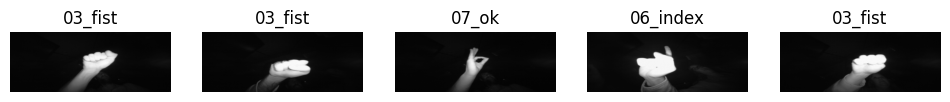

In [4]:
import matplotlib.pyplot as plt
import random

# Visualize some training images
plt.figure(figsize=(12, 8))
if os.path.exists(DATASET_PATH):
    # Collect some valid image paths
    sample_images = []
    for subject_folder in os.listdir(DATASET_PATH):
        subject_path = os.path.join(DATASET_PATH, subject_folder)
        if not os.path.isdir(subject_path): continue
        for gesture_folder in os.listdir(subject_path):
            gesture_path = os.path.join(subject_path, gesture_folder)
            if not os.path.isdir(gesture_path): continue
            images = os.listdir(gesture_path)
            if images:
                sample_images.append((gesture_folder, os.path.join(gesture_path, random.choice(images))))
    
    if sample_images:
        samples = random.sample(sample_images, min(5, len(sample_images)))
        for i, (gesture_class, img_path) in enumerate(samples):
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                plt.subplot(1, len(samples), i + 1)
                plt.imshow(img)
                plt.title(gesture_class)
                plt.axis('off')
        plt.show()


## 5. Image Preprocessing
- **Resize images:** Standardize the size of all images for the CNN.
- **Normalize pixel values:** Scale pixel values from 0-255 to 0-1.
- **Encode labels:** Convert string labels to numerical format.

In [5]:
IMG_SIZE = 64 # Resize all images to 64x64
data = []
labels = []
classes_dict = {}
class_index = 0
if os.path.exists(DATASET_PATH):
    for subject_folder in os.listdir(DATASET_PATH):
        subject_path = os.path.join(DATASET_PATH, subject_folder)
        if not os.path.isdir(subject_path): continue
        
        for gesture_folder in os.listdir(subject_path):
            gesture_path = os.path.join(subject_path, gesture_folder)
            if not os.path.isdir(gesture_path): continue
                
            if gesture_folder not in classes_dict:
                classes_dict[gesture_folder] = class_index
                class_index += 1
                
            current_class_idx = classes_dict[gesture_folder]
            
            for img_name in os.listdir(gesture_path):
                img_path = os.path.join(gesture_path, img_name)
                img = cv2.imread(img_path)
                if img is None: continue
                    
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                data.append(img)
                labels.append(current_class_idx)
    classes = list(classes_dict.keys())
    idx_to_class = {v: k for k, v in classes_dict.items()}
    # Convert to numpy arrays
    data = np.array(data, dtype='float32') / 255.0
    labels = np.array(labels)
    if len(labels) > 0:
        labels = to_categorical(labels, num_classes=len(classes_dict))
        print(f"Data shape: {data.shape}")
        print(f"Labels shape: {labels.shape}")


Data shape: (15030, 64, 64, 3)
Labels shape: (15030, 10)


## 6. Visualize Sample Images

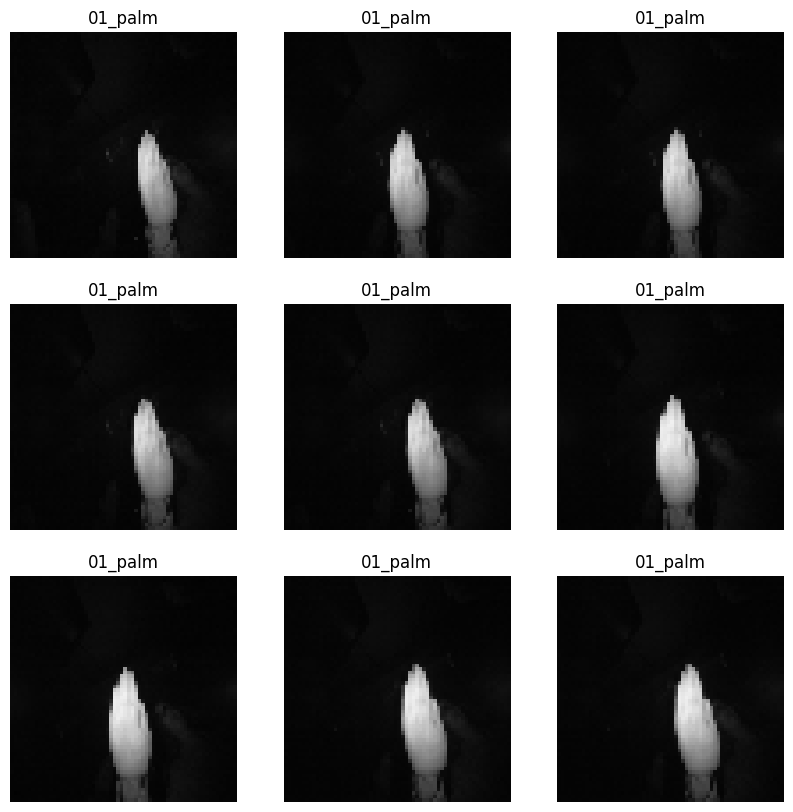

In [6]:
if len(data) > 0:
    plt.figure(figsize=(10, 10))
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(cv2.cvtColor(data[i], cv2.COLOR_BGR2RGB))
        # Get the actual class name
        label_idx = np.argmax(labels[i])
        plt.title(idx_to_class[label_idx])
        plt.axis('off')
    plt.show()

## 7. Split Dataset into Training and Testing Sets

In [7]:
if len(data) > 0:
    X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)
    print(f"Training data shape: {X_train.shape}")
    print(f"Testing data shape: {X_test.shape}")

Training data shape: (12024, 64, 64, 3)
Testing data shape: (3006, 64, 64, 3)


## 8. Build a CNN Model

In [8]:
if len(data) > 0:
    num_classes = len(classes)

    model = Sequential()
    
    # 1st Convolutional Layer
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    
    # 2nd Convolutional Layer
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    
    # 3rd Convolutional Layer
    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    
    # Flatten the results to feed into a DNN
    model.add(Flatten())
    
    # Fully Connected Layer
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5)) # Prevent overfitting
    
    # Output Layer
    model.add(Dense(num_classes, activation='softmax'))
    
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    model.summary()

C:\Users\impan\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 684,490 (2.61 MB)

 Trainable params: 684,490 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

## 9. Train the Model

In [9]:
if len(data) > 0:
    EPOCHS = 15
    BATCH_SIZE = 32

    history = model.fit(
        X_train, y_train, 
        epochs=EPOCHS, 
        batch_size=BATCH_SIZE,
        validation_data=(X_test, y_test)
    )

Epoch 1/15


  1/376 ━━━━━━━━━━━━━━━━━━━━ 14:49:48 142s/step - accuracy: 0.1562 - loss: 2.2800

  2/376 ━━━━━━━━━━━━━━━━━━━━ 2:55 469ms/step - accuracy: 0.1719 - loss: 2.2922   

  3/376 ━━━━━━━━━━━━━━━━━━━━ 2:22 383ms/step - accuracy: 0.1736 - loss: 2.2901

  4/376 ━━━━━━━━━━━━━━━━━━━━ 2:19 376ms/step - accuracy: 0.1673 - loss: 2.2911

...

373/376 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.9961 - loss: 0.0113

374/376 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.9961 - loss: 0.0113

375/376 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.9961 - loss: 0.0113

376/376 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.9961 - loss: 0.0113

376/376 ━━━━━━━━━━━━━━━━━━━━ 92s 161ms/step - accuracy: 0.9977 - loss: 0.0065 - val_accuracy: 0.9997 - val_loss: 5.3626e-04


## 10. Plot Training & Validation Accuracy

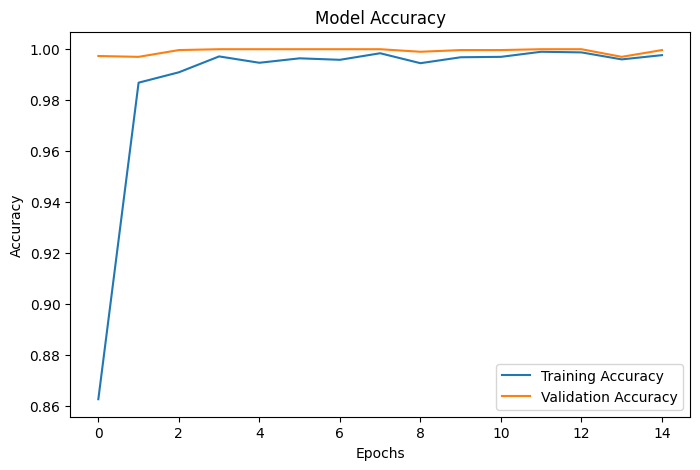

In [10]:
if len(data) > 0:
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

## 11. Plot Training & Validation Loss

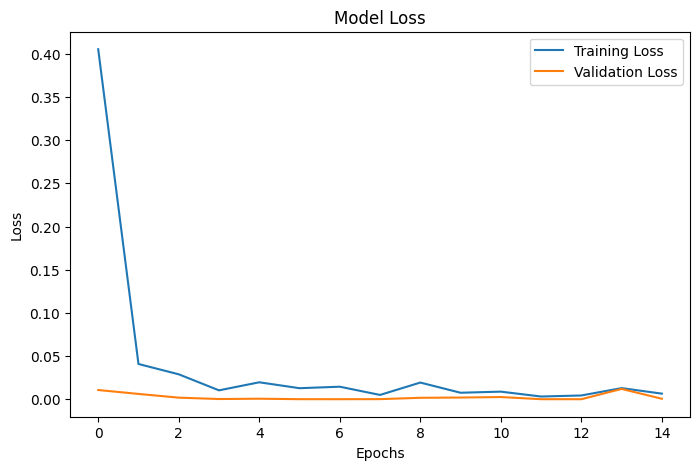

In [11]:
if len(data) > 0:
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

## 12. Evaluate the Model
- Accuracy
- Confusion Matrix
- Classification Report

 1/94 ━━━━━━━━━━━━━━━━━━━━ 32s 354ms/step

 2/94 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step  

 3/94 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step

 5/94 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step

 7/94 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step

...

91/94 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step

93/94 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step

94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step


Test Accuracy: 99.97%


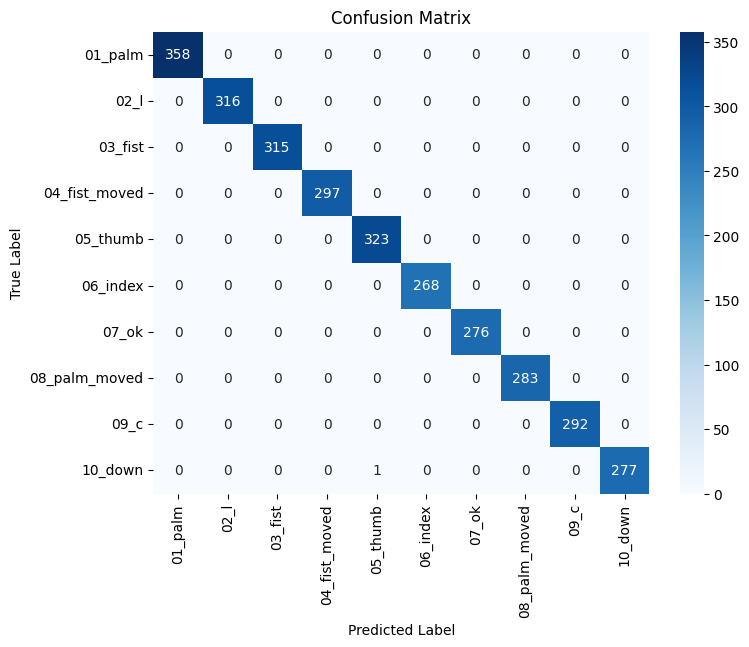

Classification Report:

               precision    recall  f1-score   support

      01_palm       1.00      1.00      1.00       358
         02_l       1.00      1.00      1.00       316
      03_fist       1.00      1.00      1.00       315
04_fist_moved       1.00      1.00      1.00       297
     05_thumb       1.00      1.00      1.00       323
     06_index       1.00      1.00      1.00       268
        07_ok       1.00      1.00      1.00       276
08_palm_moved       1.00      1.00      1.00       283
         09_c       1.00      1.00      1.00       292
      10_down       1.00      1.00      1.00       278

     accuracy                           1.00      3006
    macro avg       1.00      1.00      1.00      3006
 weighted avg       1.00      1.00      1.00      3006



In [12]:
if len(data) > 0:
    # Predict on test set
    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true = np.argmax(y_test, axis=1)

    # 1. Accuracy
    test_acc = accuracy_score(y_true, y_pred_classes)
    print(f"Test Accuracy: {test_acc * 100:.2f}%")

    # 2. Confusion Matrix
    cm = confusion_matrix(y_true, y_pred_classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    # 3. Classification Report
    print("Classification Report:\n")
    print(classification_report(y_true, y_pred_classes, target_names=classes))

## 13. Predict Hand Gestures for New Images
Function to upload and process a new image for prediction.

In [13]:
def predict_new_image(img_path, model, class_names):
    if not os.path.exists(img_path):
        print(f"Image not found at {img_path}")
        return None, None, None
        
    # Load and preprocess image
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
    
    img_normalized = img_resized.astype('float32') / 255.0
    img_expanded = np.expand_dims(img_normalized, axis=0)
    
    # Predict
    prediction = model.predict(img_expanded)
    predicted_class_idx = np.argmax(prediction[0])
    predicted_class_name = class_names[predicted_class_idx]
    confidence = prediction[0][predicted_class_idx]
    
    return img_rgb, predicted_class_name, confidence

## 14. Display the Predicted Image with its Label

In [14]:
# Example usage:
NEW_IMAGE_PATH = 'path_to_test_image.jpg' # Update this path to test an image

if os.path.exists(NEW_IMAGE_PATH) and len(data) > 0:
    img, label, conf = predict_new_image(NEW_IMAGE_PATH, model, classes)
    
    if img is not None:
        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        plt.title(f"Predicted: {label}\nConfidence: {conf*100:.2f}%")
        plt.axis('off')
        plt.show()
else:
    print(f"Please provide a valid path to an image in NEW_IMAGE_PATH to test.")

Please provide a valid path to an image in NEW_IMAGE_PATH to test.


In [15]:
if os.path.exists(NEW_IMAGE_PATH) and len(data) > 0:
    img = cv2.imread(NEW_IMAGE_PATH)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"Predicted: {label} ({conf*100:.2f}%)")
    plt.axis('off')
    plt.show()

## 15. Conclusion
In this project, we successfully built and trained a Convolutional Neural Network (CNN) to recognize hand gestures from images. I preprocessed the dataset, trained the model, evaluated its performance using accuracy and a confusion matrix, and demonstrated its ability to classify new, unseen images. This completes Task 04 of the SkillCraft Technology Machine Learning Internship.